In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# ile probek, jakie kolumny
df_cancer = pd.read_csv('..\\Data\\BreastCancerWisconsin_Diagnostics.csv')
print(df_cancer.shape)

df_cancer.head(1)

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


In [89]:
df_heart = pd.read_csv('..\\Data\\Heart_CardiacFeatures.csv')
print(df_heart.shape)

df_heart.head(1)

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


In [90]:
# ile jest klas M, B
count_M = df_cancer['diagnosis'].value_counts()['M']
# malignant
print("Ilosc M: ", count_M)
count_B = df_cancer['diagnosis'].value_counts()['B']
# benign
print("Ilosc B: ", count_B)

Ilosc M:  212
Ilosc B:  357


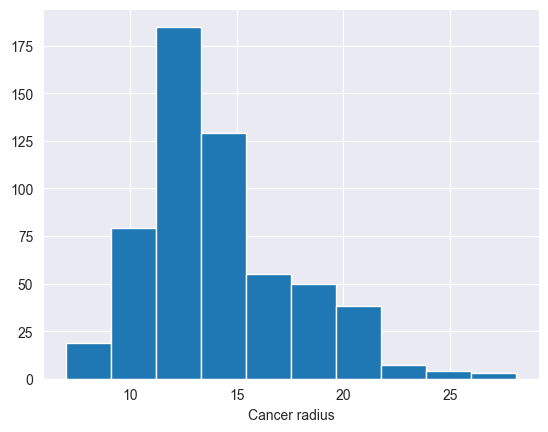

In [91]:
# histogram 1 cechy
plt.xlabel("Cancer radius")
plt.hist(df_cancer['radius_mean'])
plt.show()

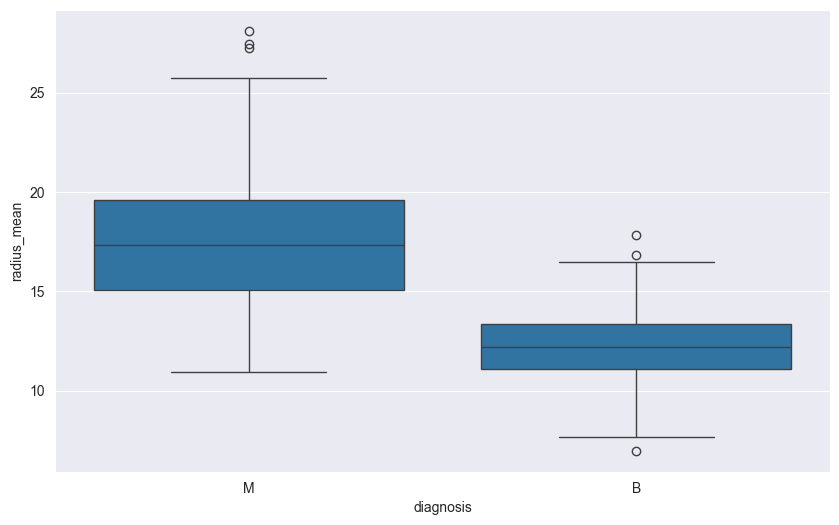

In [92]:
# boxplot cecha vs diganoza
plt.figure(figsize=(10,6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df_cancer)
plt.show()

In [93]:
# numeric_cols = df_cancer.select_dtypes(include=["int64", "float64"]).columns.drop('id')
# # print(numeric_cols)
#
# for col in numeric_cols:
#     plt.figure()
#     sns.boxplot(x='diagnosis', y=col, data=df_cancer)
#     plt.title(f"Boxplot: {col}")
#     plt.show()

Napisz kod w Pythonie z użyciem scikit‑learn, który:

tworzy X i y z ramki df dla klasyfikacji 'diagnosis' M/B,

robi train_test_split z stratify,

liczy accuracy baseline (zawsze przewiduj najczęstszą klasę).

(uzyto Copilot)

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Zakładam, że df jest już wczytany
# y = kolumna 'diagnosis' (M/B)
y = df_cancer['diagnosis']

# X = wszystkie kolumny poza 'diagnosis' i ewentualnie 'id'
X = df_cancer.drop(columns=['diagnosis', 'id'])

# Train-test split z zachowaniem proporcji klas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Obliczenie baseline accuracy:
# przewidujemy zawsze najczęstszą klasę w zbiorze treningowym
most_common_class = y_train.mode()[0]

y_pred_baseline = [most_common_class] * len(y_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Najczęstsza klasa:", most_common_class)
print("Baseline accuracy:", baseline_accuracy)


Najczęstsza klasa: B
Baseline accuracy: 0.631578947368421


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

from sklearn.metrics import classification_report, roc_auc_score

print('Logistic accuracy:', accuracy_score(y_test, lr_pred))
print('Logistic AUC:', roc_auc_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

C:\Users\Mirek-Portable\miniconda3\envs\Artificial_Inteligence\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Mirek-Portable\miniconda3\envs\Artificial_Inteligence\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Mirek-Portable\miniconda3\envs\Artificial_Inteligence\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

która cecha jest najważniejsza??

np. czy rozmiar guza jest skorelowany?

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print('RF accuracy:', accuracy_score(y_test, rf_pred))
print('RF AUC:', roc_auc_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(10)

RF accuracy: 0.9649122807017544


NameError: name 'roc_auc_score' is not defined

dla chętnych zadanie domowe

to samo z drugim dataset